# Absorption and Diffusion

This part is meant to combine all our previous results for absorption, diffusion, and convection shown in the previous three notebooks. The goal is to solve for:

\begin{equation}
\left\{\begin{aligned}
    \partial_t\rho&= D(\Delta\rho)-\mathbf{v}\cdot(\nabla\rho)-\dot m_a(\rho, \rho_s) \\
    \partial_t\rho_s&=\dot m_a(\rho, \rho_s)
\end{aligned}\right.
\end{equation}
Where $\rho$ is the density at that point and $\rho_s$ is the saturation of the metal. $D$ is the diffusivity, and $\mathbf{v}$ the velocity ($\mathbf v=(v_x, v_y)$).

Under initial condition and boundary conditions are (since there is no coupling effects of saturation of the metal I am pretty sure we do not need boundary conditions there, but I'll look into this and phrase it more rigorous):

\begin{equation}
\left\{ \begin{aligned}
    \rho(\mathbf{x}, 0)  &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_s(\mathbf{x},0) &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho(\mathbf{x}, t)  &= 1, &\forall \mathbf{x}\in\partial\Omega_1,\forall t\geq 0, \\
    \partial_\mathbf{n}\rho(\mathbf{x}, t)  &= 0, &\forall \mathbf{x}\in\partial\Omega_2,\forall t\geq 0. \\

\end{aligned}\right.
\end{equation}

where $\mathbf x = (x, y)$. the function for calculating adsorption is simplified into:

$$
\dot m(\rho, \rho_s) = k\rho(\rho_{sat}-\rho_s)
$$

We will be expanding $\rho^n$, $\rho_s^n$, and $\dot m^n$ (the values at their respective timesteps) into Lagrange polynomials:

\begin{equation*}
\begin{aligned}
\rho^n&=\sum{\rho^{n,i}\psi^i},\\
\rho_s^n&=\sum{\rho_s^{n,i}\psi^i},\\
\dot m^n&=\sum{\dot m^{n,i}\psi^i}.
\end{aligned}
\end{equation*}

we want to solve for $\rho$ and $\rho_s$, so our solution vector $\mathbf{u^n}$ becomes:

$$
\mathbf{u^n} = \begin{pmatrix}\rho^{n, 1} \\ \vdots \\ \rho^{n, N} \\ \rho_s^{n, 1} \\ \vdots \\ \rho_s^{n, N}
\end{pmatrix}
$$

We also define the vector $\mathbf{\dot{m}}$ by the coefficients of the absorption:

\begin{equation*}
\mathbf{\dot{m}}_h^n =\begin{pmatrix}
m^{n,1}\\ \vdots \\ m^{n,N}
\end{pmatrix},\\
\end{equation*}



if we discretize and apply IMEX methods (now a combination between implicit and explicit methods as discussed in the previous sections) we get:

$$
\big[M+\big( K+C\big) \Delta t \big]\mathbf{u}^{n+1}=M\big[ \mathbf u^n + \mathbf{\dot m}_h^n(\mathbf{u}^n)\, \Delta t\big]
$$

Where we have again:

$$M_{ij}=\int \psi^i\psi^j dx,\\
C_{ij}=\int (\mathbf{v}\cdot\nabla\psi^i)\psi^j \,dx,\\
K_{ij}=\int (\nabla \cdot \psi^i)(\nabla \cdot \psi^j)\, dx \\
A_{ij}=M_{ij}+\big( K_{ij}+C_{ij}\big) \Delta t $$

## Import Julia Packages 

In [332]:
using Ferrite, SparseArrays, WriteVTK, Plots

In [333]:
name = "supg";

# Stop time, time step
dt = .0005;
T = 1.3;

k = 0 ; #2.0/log(1.5);         # rate of absorption
rho_sat = 1.0;   # saturation density of metal

vx = 1.0;        # x-velocity for convection
velocity = vx;
                 # ↑ total velocity 

D = 0.001;         # Diffusivity for diffusion

h = 0.02
Pe = vx * h / (2.0*D);  # Peclet number
τ = h / (2.0 * vx) * (coth(Pe) - 1.0/Pe); # SUPG stabilization parameter

In [334]:
τ

0.009000000041223075

In [335]:
Pe

10.0

In [336]:
# generates 20 gridpoints between 
# grid = generate_grid(Quadrilateral, (100, 100), Vec((0.0, 0.0)), Vec((1.0, 1.0)));
grid = generate_grid(Line, (Int(1/h),), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(2);

ip_rho = Lagrange{RefLine, 1}();
cellvalues_rho = CellValues(qr, ip_rho);

# ip_rhos = Lagrange{RefLine, 1}()
# cellvalues_rhos = CellValues(qr, ip_rhos);

# degree of freedom handler, 
dh = DofHandler(grid)
add!(dh, :rho, ip_rho)
# add!(dh, :rho_s, ip_rhos)
close!(dh);

In [337]:
# for now we have no constraints
ch = ConstraintHandler(dh)

#create left_slit
dbc_left = Dirichlet(
    :rho,
    getfacetset(grid, "left"),
    (x, t) -> 1
)

add!(ch, dbc_left)
close!(ch)
update!(ch, 0.0)

In [338]:
function doassemble_M!(M, cellvalues_rho, dh)
    assembler = start_assemble(M)

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)

    # loop over all cells
    for cell in CellIterator(dh)
        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Me = zeros(ndofs_cell, ndofs_cell)

        # rho
        reinit!(cellvalues_rho, cell)
        for q in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q)
            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q, i)
                psi_i = shape_value(cellvalues_rho, q, i)
                wi = psi_i # + dpsi_i[1] * velocity * τ
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q, j)
                    # :rho DOFs are first in cell_dofs
                    Me[i, j] += wi * psi_j * dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Me)
    end

    return M
end

doassemble_M! (generic function with 1 method)

In [339]:
function doassemble_K!(
    K::SparseMatrixCSC, 
    cellvalues_rho::CellValues,
    dh::DofHandler
    )

    assembler = start_assemble(K)

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)

    for cell in CellIterator(dh)

        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Ke = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)
                    # D∫ (∇ψ^i) ⋅ (∇ψ^j)dx
                    Ke[i, j] += D * (dpsi_j ⋅ dpsi_i) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Ke)
    end

    return K
end


doassemble_K! (generic function with 1 method)

In [ ]:
function doassemble_C!(
    K::SparseMatrixCSC, 
    cellvalues_rho::CellValues,
    dh::DofHandler
    )

    n_basefuncs_rho = getnbasefunctions(cellvalues_rho)
    Ce = zeros(n_basefuncs_rho, n_basefuncs_rho)

    assembler = start_assemble(C)

    for cell in CellIterator(dh)
        
        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Ce = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        reinit!(cellvalues_rho, cell)
        fill!(Ce, 0)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)
                psi_i = shape_value(cellvalues_rho, q_point, i)
                wi = psi_i # + dpsi_i[1] * velocity * τ

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)
                    Ce[i, j] += (velocity ⋅ dpsi_j) *  wi * dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Ce)
    end

    return C
end


doassemble_C! (generic function with 1 method)

In [ ]:
M = allocate_matrix(dh);
K = allocate_matrix(dh);
C = allocate_matrix(dh);

M = doassemble_M!(M, cellvalues_rho, dh);
K = doassemble_K!(K, cellvalues_rho, dh);
C = doassemble_C!(C, cellvalues_rho, dh);

A = M
B = M - dt .* (K+C);

In [342]:
ndofs_total = ndofs(dh)
u_n = zeros(ndofs_total)

# Initial condition
apply_analytical!(u_n, dh, :rho, x -> 0.0)

apply!(u_n, ch)

rhsdata = get_rhs_data(ch, A);
apply!(A, ch);

In [344]:
steps_n = length(dt:dt:T)

u_hist = zeros(steps_n, ndofs_total)
rho_hist = zeros(steps_n);

In [ ]:
mdot = zeros(ndofs_total)

# finally the timeloop
for (step, t) in enumerate(dt:dt:T)
    
    #First of all, we need to update the Dirichlet boundary condition values.
    update!(ch, t)


    # b without boundary elements
    b = B * u_n 

    #Then, we can apply the boundary conditions of the current time step.
    apply_rhs!(rhsdata, b, ch)

    #Finally, we can solve the time step and save the solution afterwards.
    u = A \ b

    # #At the end of the time loop, we set the previous solution to the current one and go to the next time step.
    u_n .= u
    u_hist[step, :] .= u_n

    # keep this for plotting
    rho_hist[step] = u_n[1]

end


In [ ]:
# limits
discrete_t = collect(dt:dt:T)
discrete_x = [node.x[1] for node in getnodes(grid)]

sol_ρ = u_hist

ρmin = minimum(sol_ρ)
ρmax = maximum(sol_ρ)

left_min = ρmin
left_max = ρmax

anim = @animate for k in 2:50:length(discrete_t)
    
    p1 = plot(
        discrete_x,
        sol_ρ[k, :],
        fillrange = 0,
        fillalpha = 0.35,
        fillcolor = :dodgerblue,
        linecolor = :blue,
        label = "H₂",
        xlabel = "x",
        ylabel = "Gas fraction",
        title = "t = $(round(discrete_t[k], digits=3))",
        ylims = (0,1.3),
        legend = :topright
    )
        
    plot!(
        p1,
        discrete_x,
        sol_ρ[k, :],
        fillrange = 1,
        fillalpha = 0.35,
        fillcolor = :grey,
        linecolor = :transparent,
        label = "Other gas"
    )

    # combine
    plot(
        p1,
        layout = (2,1),
        size = (800,300)
    )

end

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_g392tw", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000043.png", "000044.png", "000045.png", "000046.png", "000047.png", "000048.png", "000049.png", "000050.png", "000051.png", "000052.png"])

[ Info: Saved animation to c:\Users\noudh\uni\MEP\1. density problem\supg\mass_transfer_supg2.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\1. density problem\\supg\\mass_transfer_supg2.gif")
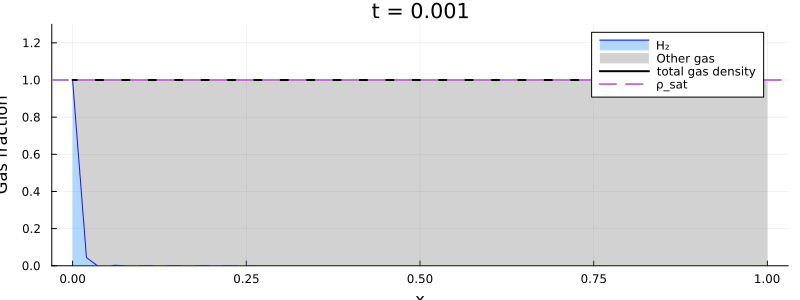

In [347]:
folder = mkpath(name)
gif(anim, joinpath(folder, "mass_transfer_supg2.gif"), fps = 300)

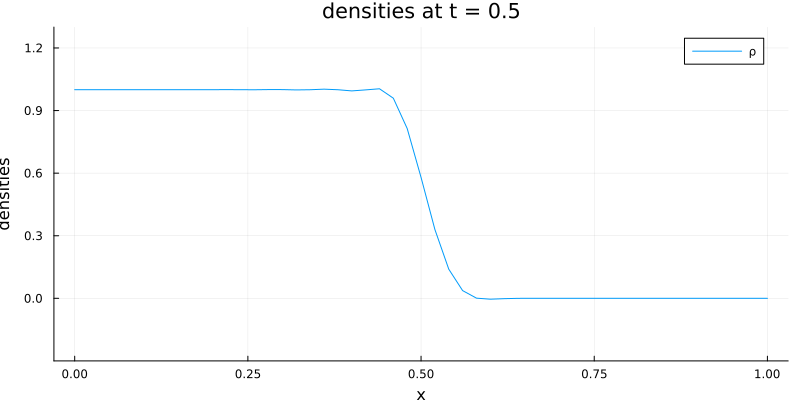

In [348]:
k = 1000

# top plot: density + total pressure
p1 = plot(
    discrete_x,
    sol_ρ[k, :],
    label = "ρ",
    # color = :blue,
    xlabel = "x",
    ylabel = "densities",
    title = "densities at t = $(round(discrete_t[k], digits=3))",
    ylims = (-.3, 1.3),
    legend = :topright,
    size = (800,400)
)


# combine
# plot(
#     p1,
#     p2,
#     layout = (2,1),
#     size = (800,600)
# )

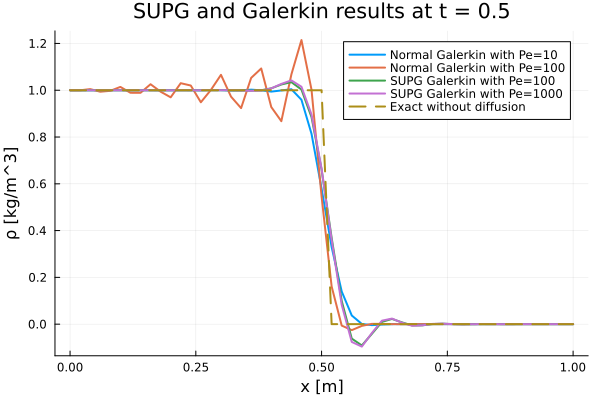

In [354]:
timestep = 1000;
k = 1000;
function rho_exact(x, t)
    t0 = t - (x/velocity)
    if t0 < 0
        return 0
    end
    return 1
end

# x-coordinates
x = [get_node_coordinate(node)[1] for node in grid.nodes];
dx = x[2] - x[1];

# values this timestep
t = dt * timestep;
# rho50 = rho_all[:, timestep];
rho_exact_vals = [rho_exact(xi, t) for xi in x];

# plot

p1 = plot( 
discrete_x,
sol_ρ[k, :],label = "Normal Galerkin with Pe=10", lw = 2, title = "SUPG and Galerkin results at t = $t", xlabel = "x [m]", ylabel = "ρ [kg/m^3]")        
plot!( p1,
discrete_x,
ρ_old[k, :],label = "Normal Galerkin with Pe=100", lw = 2)  
plot!(p1,
    discrete_x,
    ρ_new_old[k, :],label = "SUPG Galerkin with Pe=100", lw = 2)
plot!(p1,
    discrete_x,
    ρ_new_old_new[k, :],label = "SUPG Galerkin with Pe=1000", lw = 2)
# plot(x, rho50, label = "FEM", lw = 2, title = "Exact and FEM results at t = $t")
plot!(x, rho_exact_vals, label = "Exact without diffusion", lw = 2, linestyle = :dash)
xlabel!("x [m]")
ylabel!("ρ [kg/m^3]")

In [ ]:
# ρ_new_old_new = sol_ρ;

In [ ]:
# ρ_old = sol_ρ

2600×51 Matrix{Float64}:
 1.0  0.0202972  -0.00543861  0.00145727  …   7.65712e-30  -3.82856e-30
 1.0  0.0405832  -0.0104593   0.00269136     -1.27788e-29   6.82442e-30
 1.0  0.0608492  -0.0150577   0.00370911     -1.09918e-29   5.18845e-30
 1.0  0.0810865  -0.01923     0.00451761      4.72849e-30  -3.28453e-30
 1.0  0.101286   -0.0229727   0.00512424      1.73783e-29  -9.30596e-30
 1.0  0.12144    -0.0262825   0.00553664  …   1.80543e-29  -8.63325e-30
 1.0  0.141538   -0.0291568   0.0057627       7.4589e-30   -2.32478e-30
 1.0  0.161573   -0.0315931   0.00581054     -8.07774e-30   5.8141e-30
 1.0  0.181535   -0.0335894   0.00568853     -2.11678e-29   1.1833e-29
 1.0  0.201417   -0.0351442   0.00540524     -2.65337e-29   1.3266e-29
 1.0  0.221209   -0.0362562   0.00496946  …  -2.23588e-29   9.67114e-30
 1.0  0.240904   -0.0369245   0.00439017     -1.01472e-29   2.35222e-30
 1.0  0.260492   -0.0371488   0.00367654      6.32448e-30  -6.35703e-30
 ⋮                                        

In [355]:
report_figures_folder = "..\\report\\figures\\"
folder = mkpath(report_figures_folder)
name = "num_SUPG.png"
savefig(joinpath(folder, name))

"c:\\Users\\noudh\\uni\\MEP\\report\\figures\\num_SUPG.png"